In [141]:
import os
import numpy as np
from pydicom import dcmread
from icecream import ic
from skimage import morphology
from scipy import ndimage
# from skimage.measure import label, find_contours
import pickle
from numba import jit
import SimpleITK as sitk
from concurrent.futures import ProcessPoolExecutor
from time import time
import json
import nibabel as nib
import matplotlib.pyplot as plt

In [142]:
from ipywidgets import interact, IntSlider
from IPython.display import clear_output
from math import ceil

def overlay_volume_sequence_interactive(volume_seq):
    num_overlays = len(volume_seq) - 1
    nrows = ceil(num_overlays ** 0.5)
    ncols = ceil(num_overlays / nrows)
    print(f"{nrows=} {ncols=}")
    def plot_slice(slice_idx):

        fig, axes = plt.subplots(nrows, 
                                ncols, 
                                figsize=(5*ncols, 5*nrows),
                                squeeze=True)
        if nrows == 1:
            if ncols == 1:
                axes = [[axes]]
            else:
                axes = [axes]
        print(f"{axes=}")
        for i in range(num_overlays):
            ax = axes[i // ncols][i % ncols]
            print(f"{ax=}")
            ax.imshow(volume_seq[0][slice_idx], cmap="gray")
            ax.imshow(volume_seq[i+1][slice_idx], cmap="hot", alpha=0.5)
        plt.show(block=True)
    
    interact(
        plot_slice,
        slice_idx=IntSlider(
            min=0,
            max=len(volume_seq[0])-1, 
            step=1,
            value=0,
            description='Slice:'
        )
    )

def multi_vol_seq_interactive(volume_seqs, titles=None, consistent_intensity_scaling=False):
    """
    Interactive plot of multiple volume sequences using ipywidgets
    
    Parameters:
    - volume_seqs: List of 4D volume sequences to display
    - titles: Optional list of titles for each sequence
    """
    clear_output(wait=True)
    if titles is None:
        titles = [f"Volume {i+1}" for i in range(len(volume_seqs))]
        
    num_volumes = len(volume_seqs)
    nrows = int(num_volumes ** 0.5)
    ncols = (num_volumes + nrows - 1) // nrows
    
    min_max_values = []
    if not consistent_intensity_scaling:
        for volume_seq in volume_seqs:
            min_max_values.append((np.min(volume_seq), np.max(volume_seq)))
    else:
        min_max_values = [(np.min(volume_seqs), np.max(volume_seqs)) for _ in range(len(volume_seqs))]

    def plot_volumes(time_idx, slice_idx):
        fig, axes = plt.subplots(nrows, ncols, 
                                figsize=(5*ncols, 5*nrows),
                                squeeze=True)
        if nrows == 1:
            if ncols == 1:
                axes = [[axes]]
            else:
                axes = [axes]
                
        for i, (volume_seq, title) in enumerate(zip(volume_seqs, titles)):
            row, col = i // ncols, i % ncols
            ax = axes[row][col]
            
            t = min(time_idx, len(volume_seq) - 1)
            s = min(slice_idx, len(volume_seq[t]) - 1)

            vmin, vmax = min_max_values[i]

            im = ax.imshow(volume_seq[t][s], cmap='magma', vmin=vmin, vmax=vmax)
            ax.set_title(title)
            plt.colorbar(im, ax=ax)
            
        plt.tight_layout()
        # plt.show()
        
    max_time = max(len(vol) for vol in volume_seqs) - 1
    max_slice = max(len(vol[0]) for vol in volume_seqs) - 1
    
    interact(
        plot_volumes,
        time_idx=IntSlider(min=0, max=max_time, step=1, value=0, description='Time:'),
        slice_idx=IntSlider(min=0, max=max_slice, step=1, value=0, description='Slice:')
    )


from IPython.display import clear_output
# Callback invoked when the StartEvent happens, sets up our new data.
def start_plot():
    global metric_values, multires_iterations

    metric_values = []
    multires_iterations = []


# Callback invoked when the EndEvent happens, do cleanup of data and figure.
def end_plot():
    global metric_values, multires_iterations

    del metric_values
    del multires_iterations
    # Close figure, we don't want to get a duplicate of the plot latter on.
    plt.close()


# Callback invoked when the IterationEvent happens, update our data and display new figure.
def plot_values(registration_method, metric_name='Metric Value'):
    if registration_method.GetOptimizerIteration() % 10 == 0:
        global metric_values, multires_iterations

        metric_values.append(registration_method.GetMetricValue())
        # Clear the output area (wait=True, to reduce flickering), and plot current data
        clear_output(wait=True)
        # Plot the similarity metric values
        plt.plot(metric_values, "r")
        plt.plot(
            multires_iterations,
            [metric_values[index] for index in multires_iterations],
            "b*",
        )
        plt.xlabel("Iteration Number", fontsize=12)
        plt.ylabel(metric_name, fontsize=12)
        plt.show()


# Callback invoked when the sitkMultiResolutionIterationEvent happens, update the index into the
# metric_values list.
def update_multires_iterations():
    global metric_values, multires_iterations
    multires_iterations.append(len(metric_values))

In [143]:
uncentered = np.load('Experiments/QualityFiltered/MOL-102.npy')

FileNotFoundError: [Errno 2] No such file or directory: 'Experiments/QualityFiltered/MOL-1.npy'

In [144]:
def center_scan_on_hw_plane(volume_seq: np.ndarray) -> np.ndarray:
    """
    Centers a preprocessed 4D scan (T, D, H, W) on the H-W plane.
    The centering is based on the centroid of a reference slice.
    It assumes the input scan is skull-stripped with background values of 0.

    Args:
        volume_seq (np.ndarray): The 4D input scan, typically with shape 
                                 (Time, Depth, Height, Width).
                                 Background is assumed to be 0.

    Returns:
        np.ndarray: The centered 4D scan. Returns the original scan if
                    the reference slice is empty or centroid calculation fails.
    """
    if not isinstance(volume_seq, np.ndarray) or volume_seq.ndim != 4:
        raise ValueError("Input 'volume_seq' must be a 4D NumPy array.")

    T, D, H_dim_size, W_dim_size = volume_seq.shape

    # Select the reference slice (middle volume, middle depth slice)
    ref_time_idx = T // 2
    ref_depth_idx = D // 2
    reference_slice = volume_seq[ref_time_idx, ref_depth_idx, :, :]

    # Calculate the centroid of the brain in the reference slice
    # ndimage.center_of_mass returns (h_coord, w_coord)
    binary_reference_mask = reference_slice > 0  # Or use a specific threshold if needed, e.g., > 0.01

    if np.sum(binary_reference_mask) == 0:
        print("Warning: Binary mask of reference slice is empty. Returning original scan.")
        return np.copy(volume_seq)

    try:
        centroid_h, centroid_w = ndimage.center_of_mass(binary_reference_mask)
    except Exception as e:
        print(f"Warning: Error calculating center_of_mass: {e}. Returning original scan.")
        return np.copy(volume_seq)

    # Desired center of the H-W plane.
    # For an image of size N, pixel indices 0 to N-1, the geometric center is (N-1)/2.0
    actual_H_dim_size = reference_slice.shape[0]
    actual_W_dim_size = reference_slice.shape[1]
    
    target_center_h = (actual_H_dim_size - 1) / 2.0
    target_center_w = (actual_W_dim_size - 1) / 2.0

    # Calculate the shift needed
    shift_h = target_center_h - centroid_h
    shift_w = target_center_w - centroid_w

    # Prepare the output array
    centered_volume_seq = np.zeros_like(volume_seq)

    # Apply the same 2D shift to all H-W slices in the 4D volume
    for t in range(T):
        for d_idx in range(D): # Renamed d to d_idx to avoid conflict with scipy.ndimage
            current_slice = volume_seq[t, d_idx, :, :]
            # Apply shift with bilinear interpolation and 0 padding for background
            centered_slice = ndimage.shift(
                current_slice,
                shift=(shift_h, shift_w), # Shift for (Height, Width) axes
                order=1,                  # Bilinear interpolation
                mode='constant',
                cval=0.0                  # Background value, assuming normalized input
            )
            centered_volume_seq[t, d_idx, :, :] = centered_slice
            
    return centered_volume_seq

In [145]:
def symmetric_centering(
    volume_seq: np.ndarray,
    num_reference_slices: int = 3,
    default_pixel_value: float = 0.0,
    max_step = 4.0,
    relaxation_factor = 0.5,
    shrink_factors = [4, 1],
    smoothing_sigmas = [2, 0],
    lr = 0.1,
    n_iters = 150,
    gradient_magnitude_tolerance: float = 1e-5, 
    min_step: float = 5e-3,
    multi_res: bool = True,
    verbose: bool = True,
    ) -> np.ndarray:

    if not isinstance(volume_seq, np.ndarray) or volume_seq.ndim != 4:
        raise ValueError("Input 'volume_seq' must be a 4D NumPy array.")

    T, D, H_dim, W_dim = volume_seq.shape
    symmetrized_volume_seq = np.copy(volume_seq)
    typed_default_pixel_value = volume_seq.dtype.type(default_pixel_value)
    # start = D - D // 3
    # end = min(start + num_reference_slices, D)
    proj_slice = np.sum(volume_seq[0], axis=0)
    
    if proj_slice.dtype != np.float32:
        proj_slice = proj_slice.astype(np.float32)

    # overlay plot during registration
    def plot_overlay(fixed_img, moving_img, iteration):
        clear_output(wait=True)
        
        plt.clf()  # Clear current figure
        plt.imshow(moving_img, cmap='hot', vmin=np.min(moving_img), vmax=np.max(moving_img))
        plt.imshow(fixed_img, cmap='Greys_r', alpha=0.5, vmin=np.min(fixed_img), vmax=np.max(fixed_img))
        plt.title(f'Registration Progress - Iteration {iteration}')
        plt.axis('off')
        plt.tight_layout()
        plt.show(block=True)


    moving_sitk_image = sitk.GetImageFromArray(proj_slice)
    moving_sitk_image.SetSpacing([1.0, 1.0])

    mirrored_proj_slice = np.fliplr(proj_slice).copy()
    fixed_sitk_image = sitk.GetImageFromArray(mirrored_proj_slice)
    fixed_sitk_image.SetSpacing([1.0, 1.0])

    # REMOVED: CenteredTransformInitializer, using our manual initial_centering_transform
    initial_transform = sitk.CenteredTransformInitializer(
        fixed_sitk_image, moving_sitk_image, sitk.Euler2DTransform(),
        sitk.CenteredTransformInitializerFilter.GEOMETRY
    )
    
    registration_method = sitk.ImageRegistrationMethod()
    registration_method.SetMetricAsMeanSquares()
    
    # Optimizer settings
    registration_method.SetOptimizerAsRegularStepGradientDescent(
        learningRate=lr,
        maximumStepSizeInPhysicalUnits=max_step,
        minStep=min_step,
        numberOfIterations=n_iters,
        gradientMagnitudeTolerance=gradient_magnitude_tolerance,
        relaxationFactor=relaxation_factor,
        estimateLearningRate=sitk.ImageRegistrationMethod.EachIteration
    )

    if multi_res:
        registration_method.SetShrinkFactorsPerLevel(shrinkFactors=shrink_factors)
        registration_method.SetSmoothingSigmasPerLevel(smoothingSigmas=smoothing_sigmas)
        registration_method.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

    registration_method.SetInitialTransform(initial_transform)
    registration_method.SetInterpolator(sitk.sitkLinear)

    def command_iteration(method):
        if (method.GetOptimizerIteration()) % 10 == 0:
            # Get current transform and apply to moving image
            transform = method.GetInitialTransform()
            transformed = sitk.Resample(
                moving_sitk_image, fixed_sitk_image,
                transform,
                sitk.sitkLinear,
                0.0,
                moving_sitk_image.GetPixelID()
            )
            # Convert to numpy and plot
            current_moving = sitk.GetArrayFromImage(transformed)
            plot_overlay(mirrored_proj_slice, current_moving, method.GetOptimizerIteration())
            # print(f"Iteration: {method.GetOptimizerIteration()}")
            # print(f"Metric value: {method.GetMetricValue():.4f}")

    if verbose:
        registration_method.AddCommand(sitk.sitkIterationEvent, lambda: command_iteration(registration_method))
        # registration_method.AddCommand(sitk.sitkStartEvent, start_plot)
        # registration_method.AddCommand(sitk.sitkEndEvent, end_plot)
        # registration_method.AddCommand(sitk.sitkMultiResolutionIterationEvent, update_multires_iterations)
        # registration_method.AddCommand(sitk.sitkIterationEvent, lambda: plot_values(registration_method, 'MSE'))
    try:
        final_transform_full = registration_method.Execute(fixed_sitk_image, moving_sitk_image)
        transform = final_transform_full.GetParameters()
        center_full = final_transform_full.GetCenter()

        angle_half = transform[0] / 2.0
        tx_half = transform[1] / 2.0
        ty_half = transform[2] / 2.0

        global_transform = sitk.Euler2DTransform()
        global_transform.SetAngle(angle_half)
        global_transform.SetTranslation((tx_half, ty_half))
        global_transform.SetCenter((center_full[0], center_full[1]))
    except Exception as e:
        print(f"Error deriving transform: {e}. Returning original scan.")
        return symmetrized_volume_seq # Original copied array

    resampler = sitk.ResampleImageFilter()
    resampler.SetTransform(global_transform)
    resampler.SetInterpolator(sitk.sitkLinear)

    for t_idx in range(T):
        for d_slice_idx in range(D): # Renamed to avoid confusion with SimpleITK's 'd'
            current_slice_np = volume_seq[t_idx, d_slice_idx, :, :]
            
            # Convert slice to float32 for SITK processing, if not already
            current_slice_sitk = sitk.GetImageFromArray(current_slice_np)
            current_slice_sitk.SetSpacing([1.0, 1.0]) # Important: Ensure consistent physical space

            # Set reference image for resampler to define output space
            resampler.SetReferenceImage(current_slice_sitk)
            resampler.SetDefaultPixelValue(float(typed_default_pixel_value))
            try:
                symmetrized_sitk_slice = resampler.Execute(current_slice_sitk)
                symmetrized_slice_np = sitk.GetArrayFromImage(symmetrized_sitk_slice).astype(volume_seq.dtype, copy=False)
                symmetrized_volume_seq[t_idx, d_slice_idx, :, :] = symmetrized_slice_np
            except RuntimeError as e:
                 print(f"Resampling failed for slice (t={t_idx}, d={d_slice_idx}): {e}. Using original slice for this instance.")
                 # symmetrized_volume_seq already contains the original slice here

    print("Global symmetry correction applied.")
    return symmetrized_volume_seq


In [146]:
import numpy as np
import SimpleITK as sitk
from scipy import ndimage # For center_of_mass
from IPython.display import clear_output # For plotting in Jupyter
import matplotlib.pyplot as plt # For plotting

def symmetric_centering(
    volume_seq: np.ndarray,
    default_pixel_value: float = 0.0,
    # Parameters for symmetry registration optimizer
    max_step_sym_reg: float = 4.0,
    relaxation_factor_sym_reg: float = 0.5,
    lr_sym_reg: float = 0.1,
    n_iters_sym_reg: int = 150,
    gradient_magnitude_tolerance_sym_reg: float = 1e-5,
    min_step_sym_reg: float = 5e-3,
    # Multi-resolution for symmetry registration
    multi_res_sym_reg: bool = True,
    shrink_factors_sym_reg = [4, 1],
    smoothing_sigmas_sym_reg = [2, 0],
    # Threshold for creating binary mask for centroid calculation
    centroid_mask_threshold_quantile: float = 0.1,
    verbose: bool = True
    ) -> np.ndarray:

    if not isinstance(volume_seq, np.ndarray) or volume_seq.ndim != 4:
        raise ValueError("Input 'volume_seq' must be a 4D NumPy array.")

    T, D, H_dim, W_dim = volume_seq.shape
    symmetrized_volume_seq = np.copy(volume_seq)
    typed_default_pixel_value = type(default_pixel_value)(default_pixel_value)

    if T == 0 or D == 0:
        print("Warning: Empty volume sequence (T=0 or D=0). Returning original scan.")
        return symmetrized_volume_seq

    # --- Step 1: Prepare the original projection slice from the first volume (t=0) ---
    original_proj_slice_np = np.sum(volume_seq[0], axis=0) # Sum over depth dimension
    
    if original_proj_slice_np.dtype != np.float32:
        original_proj_slice_np = original_proj_slice_np.astype(np.float32)

    H_proj, W_proj = original_proj_slice_np.shape
    original_proj_slice_sitk = sitk.GetImageFromArray(original_proj_slice_np)
    original_proj_slice_sitk.SetSpacing([1.0, 1.0])


    # --- Step 2: Calculate T_center_only (Pure Centering Transform for original_proj_slice_np) ---
    T_center_only = sitk.Euler2DTransform() 
    geometric_center_proj_np_sitk_coords = ((W_proj - 1) / 2.0, (H_proj - 1) / 2.0)
    T_center_only.SetCenter(geometric_center_proj_np_sitk_coords)

    binary_mask_proj_orig = original_proj_slice_np > 0

    try:
        centroid_h, centroid_w = ndimage.center_of_mass(binary_mask_proj_orig)
        target_center_h = (H_proj - 1) / 2.0
        target_center_w = (W_proj - 1) / 2.0
        shift_h_center = centroid_h - target_center_h
        shift_w_center = centroid_w - target_center_w
        T_center_only.SetTranslation((shift_w_center, shift_h_center))
        if verbose:
            print(f"Centering transform (T_center_only) calculated. Shift (dw, dh): ({shift_w_center:.2f}, {shift_h_center:.2f}) px.")
    except Exception as e:
        print(f"Warning: Could not calculate centroid for T_center_only: {e}. T_center_only remains identity.")

    # --- Step 3: Apply T_center_only to get centered_proj_slice ---
    resampler_for_centering = sitk.ResampleImageFilter()
    resampler_for_centering.SetReferenceImage(original_proj_slice_sitk) # Output grid same as original
    resampler_for_centering.SetTransform(T_center_only)
    resampler_for_centering.SetInterpolator(sitk.sitkLinear)
    resampler_for_centering.SetDefaultPixelValue(typed_default_pixel_value) # Use original background
    
    centered_proj_slice_sitk = resampler_for_centering.Execute(original_proj_slice_sitk)
    centered_proj_slice_np = sitk.GetArrayFromImage(centered_proj_slice_sitk)

    if verbose:
        plt.figure(figsize=(12, 4))
        plt.subplot(1,3,1); plt.imshow(original_proj_slice_np, cmap='gray'); plt.title('Original Projection'); plt.axis('off')
        plt.subplot(1,3,2); plt.imshow(centered_proj_slice_np, cmap='gray'); plt.title('Centered Projection'); plt.axis('off')
        # For the third plot, show mirrored centered projection
        mirrored_centered_np = np.fliplr(centered_proj_slice_np).copy()
        plt.subplot(1,3,3); plt.imshow(mirrored_centered_np, cmap='gray'); plt.title('Mirrored Centered Proj.'); plt.axis('off')
        plt.tight_layout()
        plt.show()


    # --- Step 4: Calculate T_symmetry_on_centered_half (Symmetry Correction on *centered* proj_slice) ---
    mirrored_centered_proj_slice_np = np.fliplr(centered_proj_slice_np).copy()

    def plot_overlay(fixed_img, moving_img, iteration):
        clear_output(wait=True)
        plt.clf()  # Clear current figure
        plt.imshow(moving_img, cmap='hot', vmin=np.min(moving_img), vmax=np.max(moving_img))
        plt.imshow(fixed_img, cmap='Greys_r', alpha=0.5, vmin=np.min(fixed_img), vmax=np.max(fixed_img))
        plt.title(f'Registration Progress - Iteration {iteration}')
        plt.axis('off')
        plt.tight_layout()
        plt.show(block=True)


    moving_sitk_for_sym = sitk.GetImageFromArray(centered_proj_slice_np) # Use centered version
    moving_sitk_for_sym.SetSpacing([1.0, 1.0])

    fixed_sitk_for_sym = sitk.GetImageFromArray(mirrored_centered_proj_slice_np) # Mirrored centered version
    fixed_sitk_for_sym.SetSpacing([1.0, 1.0])

    initial_transform_sym_reg = sitk.CenteredTransformInitializer(
        fixed_sitk_for_sym, 
        moving_sitk_for_sym, 
        sitk.Euler2DTransform(),
        sitk.CenteredTransformInitializerFilter.GEOMETRY
    )
    
    registration_method = sitk.ImageRegistrationMethod()
    registration_method.SetMetricAsMeanSquares() 
    registration_method.SetOptimizerAsRegularStepGradientDescent(
        learningRate=lr_sym_reg,
        maximumStepSizeInPhysicalUnits=max_step_sym_reg,
        minStep=min_step_sym_reg,
        numberOfIterations=n_iters_sym_reg,
        gradientMagnitudeTolerance=gradient_magnitude_tolerance_sym_reg,
        relaxationFactor=relaxation_factor_sym_reg,
        estimateLearningRate=sitk.ImageRegistrationMethod.EachIteration
    )

    if multi_res_sym_reg:
        registration_method.SetShrinkFactorsPerLevel(shrinkFactors=shrink_factors_sym_reg)
        registration_method.SetSmoothingSigmasPerLevel(smoothingSigmas=smoothing_sigmas_sym_reg)
        registration_method.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

    registration_method.SetInitialTransform(initial_transform_sym_reg)
    registration_method.SetInterpolator(sitk.sitkLinear)

    T_symmetry_on_centered_half = sitk.Euler2DTransform()

    # Store the transform being optimized by the method
    current_transform_being_optimized_sym = sitk.Euler2DTransform(initial_transform_sym_reg)
    registration_method.SetInitialTransform(current_transform_being_optimized_sym, inPlace=True)


    def command_iteration(method):
        if (method.GetOptimizerIteration()) % 10 == 0:
            # Get current transform and apply to moving image
            transform = method.GetInitialTransform()
            transformed = sitk.Resample(
                moving_sitk_for_sym, fixed_sitk_for_sym,
                transform,
                sitk.sitkLinear,
                0.0,
                moving_sitk_for_sym.GetPixelID()
            )
            # Convert to numpy and plot
            current_moving = sitk.GetArrayFromImage(transformed)
            plot_overlay(mirrored_centered_proj_slice_np, current_moving, method.GetOptimizerIteration())
            # print(f"Iteration: {method.GetOptimizerIteration()}")
            # print(f"Metric value: {method.GetMetricValue():.4f}")

    if verbose:
        registration_method.AddCommand(sitk.sitkIterationEvent, lambda: command_iteration(registration_method))
    try:
        # Execute modifies current_transform_being_optimized_sym in place
        registration_method.Execute(fixed_sitk_for_sym, moving_sitk_for_sym)
        final_transform_sym_full = current_transform_being_optimized_sym # This now holds the result
        
        params_sym_full = final_transform_sym_full.GetParameters()
        center_sym_full = final_transform_sym_full.GetCenter()

        angle_sym_half = params_sym_full[0] / 2.0
        tx_sym_half = params_sym_full[1] / 2.0
        ty_sym_half = params_sym_full[2] / 2.0

        T_symmetry_on_centered_half.SetAngle(angle_sym_half)
        T_symmetry_on_centered_half.SetTranslation((tx_sym_half, ty_sym_half))
        T_symmetry_on_centered_half.SetCenter(center_sym_full)
        if verbose:
            print(f"Symmetry registration on centered (T_symmetry_on_centered_half) calculated. Angle: {np.degrees(angle_sym_half):.2f} deg, "
                  f"Translation: ({tx_sym_half:.2f}, {ty_sym_half:.2f}) px, Center: ({center_sym_full[0]:.2f}, {center_sym_full[1]:.2f}) px.")
    except RuntimeError as e:
        print(f"SITK Symmetry Registration on centered slice failed: {e}. T_symmetry_on_centered_half remains identity.")
    except Exception as e:
        print(f"Error deriving T_symmetry_on_centered_half: {e}. T_symmetry_on_centered_half remains identity.")

    # --- Step 5: Create Global Composite Transform ---
    T_global_composite = sitk.CompositeTransform(2)
    T_global_composite.AddTransform(T_center_only)                     # Applied first
    T_global_composite.AddTransform(T_symmetry_on_centered_half)   # Applied second

    # --- Step 6: Apply the final T_global_composite to all slices of original volume_seq ---
    resampler_global = sitk.ResampleImageFilter()
    resampler_global.SetTransform(T_global_composite)
    resampler_global.SetInterpolator(sitk.sitkLinear)

    for t_idx in range(T):
        for d_slice_idx in range(D):
            current_slice_np_orig = volume_seq[t_idx, d_slice_idx, :, :] # Apply to original slices
            current_slice_sitk_orig = sitk.GetImageFromArray(current_slice_np_orig.astype(np.float32, copy=False))
            current_slice_sitk_orig.SetSpacing([1.0, 1.0])

            resampler_global.SetReferenceImage(current_slice_sitk_orig) # Output grid same as this slice
            resampler_global.SetDefaultPixelValue(typed_default_pixel_value)

            try:
                symmetrized_sitk_slice = resampler_global.Execute(current_slice_sitk_orig)
                symmetrized_slice_np = sitk.GetArrayFromImage(symmetrized_sitk_slice).astype(volume_seq.dtype, copy=False)
                symmetrized_volume_seq[t_idx, d_slice_idx, :, :] = symmetrized_slice_np
            except RuntimeError as e:
                 if verbose:
                     print(f"Global resampling failed for slice (t={t_idx}, d={d_slice_idx}): {e}. Using original.")

    if verbose:
        print("Global composite (explicit centering then symmetry on centered) correction applied.")
    return symmetrized_volume_seq


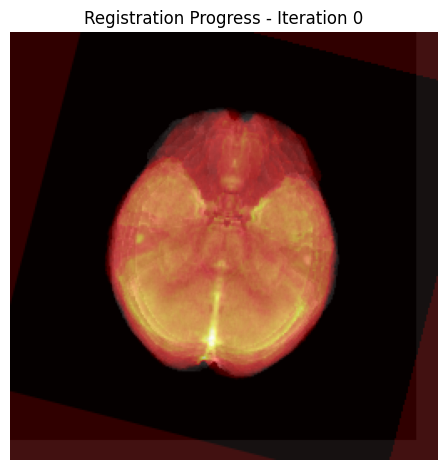

Symmetry registration on centered (T_symmetry_on_centered_half) calculated. Angle: -4.92 deg, Translation: (0.02, -0.00) px, Center: (127.50, 127.50) px.
Global composite (explicit centering then symmetry on centered) correction applied.


In [147]:
sym = symmetric_centering(uncentered)

In [148]:
multi_vol_seq_interactive([uncentered, sym])

interactive(children=(IntSlider(value=0, description='Time:', max=17), IntSlider(value=0, description='Slice:'…

In [134]:
def center_scans(save_dir: str, src_dir: str='QualityFiltered'):
    for path in os.listdir(src_dir):
        scan = np.load(os.path.join(src_dir, path))
        scan = symmetric_centering(scan, verbose=False)
        if not os.path.exists(save_dir):
            os.makedirs(save_dir)
        np.save(os.path.join(save_dir, path), scan)
center_scans('Experiments/SymmetricCentered')

In [137]:
center_scans(save_dir='ISLES_PreprocessedData', src_dir='Experiments/ISLES_PreprocessedData')

In [115]:
centered = center_scan_on_hw_plane(uncentered)

## OLD STUFF DOWN HERE

In [117]:
multi_vol_seq_interactive([centered, uncentered])

interactive(children=(IntSlider(value=0, description='Time:', max=17), IntSlider(value=0, description='Slice:'…

In [28]:
unsymmetric = np.load('Experiments/QualityFiltered/MOL-101.npy')

This was a previous version of the symmetric_centering function without initial centering. This would lead to unstable registration with scans too off-center.

In [105]:
def symmetric_centering(
    volume_seq: np.ndarray,
    num_reference_slices: int = 3,
    default_pixel_value: float = 0.0,
    max_step = 4.0,
    relaxation_factor = 0.5,
    shrink_factors = [4, 1],
    smoothing_sigmas = [2, 0],
    lr = 0.1,
    n_iters = 150,
    gradient_magnitude_tolerance: float = 1e-5, 
    min_step: float = 5e-3,
    multi_res: bool = True,
    verbose: bool = True,
    ) -> np.ndarray:

    if not isinstance(volume_seq, np.ndarray) or volume_seq.ndim != 4:
        raise ValueError("Input 'volume_seq' must be a 4D NumPy array.")

    T, D, H_dim, W_dim = volume_seq.shape
    symmetrized_volume_seq = np.copy(volume_seq)
    typed_default_pixel_value = volume_seq.dtype.type(default_pixel_value)
    # start = D - D // 3
    # end = min(start + num_reference_slices, D)
    proj_slice = np.sum(volume_seq[0], axis=0)
    
    if proj_slice.dtype != np.float32:
        proj_slice = proj_slice.astype(np.float32)

    # overlay plot during registration
    def plot_overlay(fixed_img, moving_img, iteration):
        clear_output(wait=True)
        
        plt.clf()  # Clear current figure
        plt.imshow(moving_img, cmap='hot', vmin=np.min(moving_img), vmax=np.max(moving_img))
        plt.imshow(fixed_img, cmap='Greys_r', alpha=0.5, vmin=np.min(fixed_img), vmax=np.max(fixed_img))
        plt.title(f'Registration Progress - Iteration {iteration}')
        plt.axis('off')
        plt.tight_layout()
        plt.show(block=True)


    moving_sitk_image = sitk.GetImageFromArray(proj_slice)
    moving_sitk_image.SetSpacing([1.0, 1.0])

    mirrored_proj_slice = np.fliplr(proj_slice).copy()
    fixed_sitk_image = sitk.GetImageFromArray(mirrored_proj_slice)
    fixed_sitk_image.SetSpacing([1.0, 1.0])

    initial_transform = sitk.CenteredTransformInitializer(
        fixed_sitk_image, moving_sitk_image, sitk.Euler2DTransform(),
        sitk.CenteredTransformInitializerFilter.GEOMETRY
    )
    registration_method = sitk.ImageRegistrationMethod()
    registration_method.SetMetricAsMeanSquares()
    
    # Optimizer settings
    registration_method.SetOptimizerAsRegularStepGradientDescent(
        learningRate=lr,
        maximumStepSizeInPhysicalUnits=max_step,
        minStep=min_step,
        numberOfIterations=n_iters,
        gradientMagnitudeTolerance=gradient_magnitude_tolerance,
        relaxationFactor=relaxation_factor,
        estimateLearningRate=sitk.ImageRegistrationMethod.EachIteration
    )

    if multi_res:
        registration_method.SetShrinkFactorsPerLevel(shrinkFactors=shrink_factors)
        registration_method.SetSmoothingSigmasPerLevel(smoothingSigmas=smoothing_sigmas)
        registration_method.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

    registration_method.SetInitialTransform(initial_transform)
    registration_method.SetInterpolator(sitk.sitkLinear)

    def command_iteration(method):
        if (method.GetOptimizerIteration()) % 10 == 0:
            # Get current transform and apply to moving image
            transform = method.GetInitialTransform()
            transformed = sitk.Resample(
                moving_sitk_image, fixed_sitk_image,
                transform,
                sitk.sitkLinear,
                0.0,
                moving_sitk_image.GetPixelID()
            )
            # Convert to numpy and plot
            current_moving = sitk.GetArrayFromImage(transformed)
            plot_overlay(mirrored_proj_slice, current_moving, method.GetOptimizerIteration())
            # print(f"Iteration: {method.GetOptimizerIteration()}")
            # print(f"Metric value: {method.GetMetricValue():.4f}")

    if verbose:
        registration_method.AddCommand(sitk.sitkIterationEvent, lambda: command_iteration(registration_method))
        # registration_method.AddCommand(sitk.sitkStartEvent, start_plot)
        # registration_method.AddCommand(sitk.sitkEndEvent, end_plot)
        # registration_method.AddCommand(sitk.sitkMultiResolutionIterationEvent, update_multires_iterations)
        # registration_method.AddCommand(sitk.sitkIterationEvent, lambda: plot_values(registration_method, 'MSE'))
    try:
        final_transform_full = registration_method.Execute(fixed_sitk_image, moving_sitk_image)
        transform = final_transform_full.GetParameters()
        center_full = final_transform_full.GetCenter()

        angle_half = transform[0] / 2.0
        tx_half = transform[1] / 2.0
        ty_half = transform[2] / 2.0

        global_transform = sitk.Euler2DTransform()
        global_transform.SetAngle(angle_half)
        global_transform.SetTranslation((tx_half, ty_half))
        global_transform.SetCenter((center_full[0], center_full[1]))
    except Exception as e:
        print(f"Error deriving transform: {e}. Returning original scan.")
        return symmetrized_volume_seq # Original copied array

    resampler = sitk.ResampleImageFilter()
    resampler.SetTransform(global_transform)
    resampler.SetInterpolator(sitk.sitkLinear)

    for t_idx in range(T):
        for d_slice_idx in range(D): # Renamed to avoid confusion with SimpleITK's 'd'
            current_slice_np = volume_seq[t_idx, d_slice_idx, :, :]
            
            # Convert slice to float32 for SITK processing, if not already
            current_slice_sitk = sitk.GetImageFromArray(current_slice_np)
            current_slice_sitk.SetSpacing([1.0, 1.0]) # Important: Ensure consistent physical space

            # Set reference image for resampler to define output space
            resampler.SetReferenceImage(current_slice_sitk)
            resampler.SetDefaultPixelValue(float(typed_default_pixel_value))
            try:
                symmetrized_sitk_slice = resampler.Execute(current_slice_sitk)
                symmetrized_slice_np = sitk.GetArrayFromImage(symmetrized_sitk_slice).astype(volume_seq.dtype, copy=False)
                symmetrized_volume_seq[t_idx, d_slice_idx, :, :] = symmetrized_slice_np
            except RuntimeError as e:
                 print(f"Resampling failed for slice (t={t_idx}, d={d_slice_idx}): {e}. Using original slice for this instance.")
                 # symmetrized_volume_seq already contains the original slice here

    print("Global symmetry correction applied.")
    return symmetrized_volume_seq


In [ ]:
def center_scans(save_dir: str):
    for path in os.listdir('Experiments/QualityFiltered')[20:]:
        scan = np.load(os.path.join('Experiments/QualityFiltered', path))
        scan = symmetric_centering(scan, verbose=False)
        if not os.path.exists(save_dir):
            os.makedirs(save_dir)
        np.save(os.path.join(save_dir, path), scan)
center_scans('Experiments/SymmetricCentered')

Global symmetry correction applied.
Global symmetry correction applied.
Global symmetry correction applied.
Global symmetry correction applied.
Global symmetry correction applied.
Global symmetry correction applied.
Global symmetry correction applied.
Global symmetry correction applied.
Global symmetry correction applied.
Global symmetry correction applied.
Global symmetry correction applied.
Global symmetry correction applied.
Global symmetry correction applied.
Global symmetry correction applied.
Global symmetry correction applied.
Global symmetry correction applied.
Global symmetry correction applied.
Global symmetry correction applied.
Global symmetry correction applied.
Global symmetry correction applied.
Global symmetry correction applied.
Global symmetry correction applied.
Global symmetry correction applied.
Global symmetry correction applied.
Global symmetry correction applied.
Global symmetry correction applied.
Global symmetry correction applied.
Global symmetry correction a

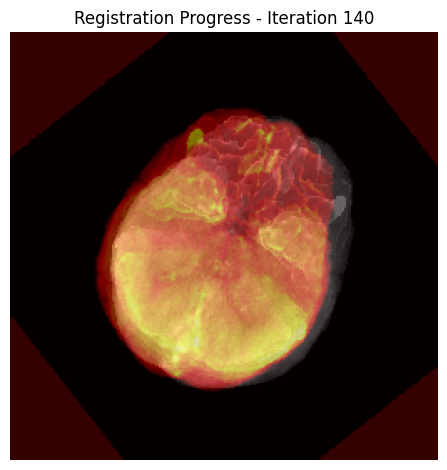

Global symmetry correction applied.


In [106]:
scan = symmetric_centering(unsymmetric)

In [150]:
multi_vol_seq_interactive([unsymmetric, scan])

interactive(children=(IntSlider(value=0, description='Time:', max=17), IntSlider(value=0, description='Slice:'…